In [3]:
import pandas as pd
import sqlite3
import numpy as np

In [4]:
locations = pd.read_csv('StormEvents_locations-ftp_v1.0_d2024_c20260116.csv.gz')
locations.sort_values('YEARMONTH')
locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41603 entries, 0 to 41602
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   YEARMONTH       41603 non-null  int64  
 1   EPISODE_ID      41603 non-null  int64  
 2   EVENT_ID        41603 non-null  int64  
 3   LOCATION_INDEX  41603 non-null  int64  
 4   RANGE           41603 non-null  float64
 5   AZIMUTH         41603 non-null  object 
 6   LOCATION        41603 non-null  object 
 7   LATITUDE        41603 non-null  float64
 8   LONGITUDE       41603 non-null  float64
 9   LAT2            41603 non-null  int64  
 10  LON2            41603 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 3.5+ MB


In [42]:
details = pd.read_csv('StormEvents_details-ftp_v1.0_d2024_c20260116.csv.gz')
details.sort_values('BEGIN_YEARMONTH')

idx = np.r_[0:6, 9, 13:17,20:44,48:51]
details.drop(details.columns[idx], axis = 1, inplace = True)

details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69801 entries, 0 to 69800
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EPISODE_ID       69801 non-null  int64  
 1   EVENT_ID         69801 non-null  int64  
 2   STATE            69801 non-null  object 
 3   YEAR             69801 non-null  int64  
 4   MONTH_NAME       69801 non-null  object 
 5   EVENT_TYPE       69801 non-null  object 
 6   BEGIN_DATE_TIME  69801 non-null  object 
 7   CZ_TIMEZONE      69801 non-null  object 
 8   END_DATE_TIME    69801 non-null  object 
 9   BEGIN_LAT        42190 non-null  float64
 10  BEGIN_LON        42190 non-null  float64
 11  END_LAT          42190 non-null  float64
 12  END_LON          42190 non-null  float64
dtypes: float64(4), int64(3), object(6)
memory usage: 6.9+ MB


In [25]:
# uncomment something to update the tables in the database

conn = sqlite3.connect('weather.db')

#locations.to_sql("locations", conn, if_exists="replace", index=False)
#details.to_sql("details", conn, if_exists="replace", index=False)

conn.close()

In [17]:
conn = sqlite3.connect('weather.db')

cmd = \
"""
SELECT D.YEAR, D.MONTH_NAME, L.EPISODE_ID, L.EVENT_ID, L.LOCATION, D.STATE,  
D.EVENT_TYPE, D.BEGIN_DATE_TIME, D.END_DATE_TIME, L.LATITUDE, L.LONGITUDE, D.BEGIN_LAT, D.BEGIN_LON, D.END_LAT, D.END_LON
FROM locations L
LEFT JOIN details D on L.EVENT_ID = D.EVENT_ID
"""

df = pd.read_sql(cmd, conn)
conn.close()

df


,YEAR,MONTH_NAME,EPISODE_ID,EVENT_ID,LOCATION,STATE,EVENT_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,LATITUDE,LONGITUDE,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON
0,2024,April,188809,1161227,HAPPY TOWN,SOUTH CAROLINA,Thunderstorm Wind,03-APR-24 04:36:00,03-APR-24 04:38:00,33.9900,-81.0900,33.9900,-81.0900,33.9900,-81.0900
1,2024,April,188809,1161228,COLUMBIA,SOUTH CAROLINA,Thunderstorm Wind,03-APR-24 04:37:00,03-APR-24 04:39:00,34.0000,-81.0200,34.0000,-81.0200,34.0000,-81.0200
2,2024,April,188809,1161229,COLUMBIA,SOUTH CAROLINA,Thunderstorm Wind,03-APR-24 04:39:00,03-APR-24 04:41:00,34.0000,-81.0100,34.0000,-81.0100,34.0000,-81.0100
3,2024,April,188809,1161230,BALLTOWN,SOUTH CAROLINA,Thunderstorm Wind,03-APR-24 03:50:00,03-APR-24 03:50:00,33.5661,-81.7300,33.5661,-81.7300,33.5661,-81.7300
4,2024,April,188809,1161231,COLUMBIA,SOUTH CAROLINA,Thunderstorm Wind,03-APR-24 04:32:00,03-APR-24 04:32:00,34.0090,-81.0210,34.0090,-81.0210,34.0090,-81.0210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41598,2024,August,196334,1215076,GRENADA,MISSISSIPPI,Thunderstorm Wind,29-AUG-24 16:25:00,29-AUG-24 16:25:00,33.7700,-89.8100,33.7700,-89.8100,33.7700,-89.8100
41599,2024,August,196334,1215079,WINONA,MISSISSIPPI,Thunderstorm Wind,29-AUG-24 16:50:00,29-AUG-24 16:50:00,33.4780,-89.7356,33.4780,-89.7356,33.4780,-89.7356
41600,2024,August,196334,1215080,COILA,MISSISSIPPI,Thunderstorm Wind,29-AUG-24 16:55:00,29-AUG-24 16:55:00,33.3800,-89.9800,33.3800,-89.9800,33.3800,-89.9800
41601,2024,August,196338,1215115,SPIRIT LAKE LAKE,IOWA,Tornado,29-AUG-24 14:05:00,29-AUG-24 14:06:00,43.4713,-95.1034,43.4713,-95.1034,43.4799,-95.0915


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41603 entries, 0 to 41602
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             41603 non-null  int64  
 1   MONTH_NAME       41603 non-null  object 
 2   EPISODE_ID       41603 non-null  int64  
 3   EVENT_ID         41603 non-null  int64  
 4   LOCATION         41603 non-null  object 
 5   STATE            41603 non-null  object 
 6   EVENT_TYPE       41603 non-null  object 
 7   BEGIN_DATE_TIME  41603 non-null  object 
 8   END_DATE_TIME    41603 non-null  object 
 9   LATITUDE         41603 non-null  float64
 10  LONGITUDE        41603 non-null  float64
 11  BEGIN_LAT        41603 non-null  float64
 12  BEGIN_LON        41603 non-null  float64
 13  END_LAT          41603 non-null  float64
 14  END_LON          41603 non-null  float64
dtypes: float64(6), int64(3), object(6)
memory usage: 4.8+ MB


In [30]:
# combining events reported with same location at same time


# making a date column
df['Date'] = df['BEGIN_DATE_TIME'].str[:10]

# adding numerical month-day col and sorting by this
df['Month_Num'] = pd.to_datetime(df['MONTH_NAME'], format='%B').dt.month
df['Day'] = df['Date'].str[:2].astype(int)

df['Month_Day'] = pd.to_datetime(dict(year=2024, month=df['Month_Num'], day=df['Day']))
df.sort_values(by='Month_Day', inplace=True)

df.drop(columns=['Date','Day'], inplace=True)
df


,YEAR,MONTH_NAME,EPISODE_ID,EVENT_ID,LOCATION,STATE,EVENT_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,LATITUDE,LONGITUDE,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,Month_Num,Month_Day
20337,2024,January,187879,1153869,FAYSON LAKES,NEW JERSEY,Flood,01-JAN-24 00:00:00,02-JAN-24 22:00:00,40.9766,-74.3471,40.7868,-74.4639,40.9766,-74.3471,1,2024-01-01
20336,2024,January,187879,1153869,GREEN POND,NEW JERSEY,Flood,01-JAN-24 00:00:00,02-JAN-24 22:00:00,41.0411,-74.4714,40.7868,-74.4639,40.9766,-74.3471,1,2024-01-01
19252,2024,January,187879,1153869,BARTLEY,NEW JERSEY,Flood,01-JAN-24 00:00:00,02-JAN-24 22:00:00,40.8406,-74.7495,40.7868,-74.4639,40.9766,-74.3471,1,2024-01-01
19251,2024,January,187879,1153869,CONVENT STATION,NEW JERSEY,Flood,01-JAN-24 00:00:00,02-JAN-24 22:00:00,40.7868,-74.4639,40.7868,-74.4639,40.9766,-74.3471,1,2024-01-01
17491,2024,January,188492,1158387,ATCHAFALAYA BAY,GULF OF MEXICO,Marine Thunderstorm Wind,03-JAN-24 06:50:00,03-JAN-24 06:50:00,28.5000,-91.5800,28.5000,-91.5800,28.5000,-91.5800,1,2024-01-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25973,2024,December,197570,1222463,ROCKWOOD,PENNSYLVANIA,Thunderstorm Wind,31-DEC-24 15:05:00,31-DEC-24 15:05:00,39.9195,-79.1525,39.9195,-79.1525,39.9195,-79.1525,12,2024-12-31
26349,2024,December,197623,1222633,FIELDCREST,WEST VIRGINIA,Thunderstorm Wind,31-DEC-24 14:05:00,31-DEC-24 14:05:00,39.6400,-79.9500,39.6400,-79.9500,39.6400,-79.9500,12,2024-12-31
27816,2024,December,197897,1223812,PYLONS DAHLGREN (PYL),ATLANTIC NORTH,Marine Thunderstorm Wind,31-DEC-24 17:41:00,31-DEC-24 17:41:00,38.3100,-77.0000,38.3100,-77.0000,38.3100,-77.0000,12,2024-12-31
26340,2024,December,197623,1222337,WATSON,WEST VIRGINIA,Thunderstorm Wind,31-DEC-24 13:35:00,31-DEC-24 13:35:00,39.4800,-80.1600,39.4800,-80.1600,39.4800,-80.1600,12,2024-12-31


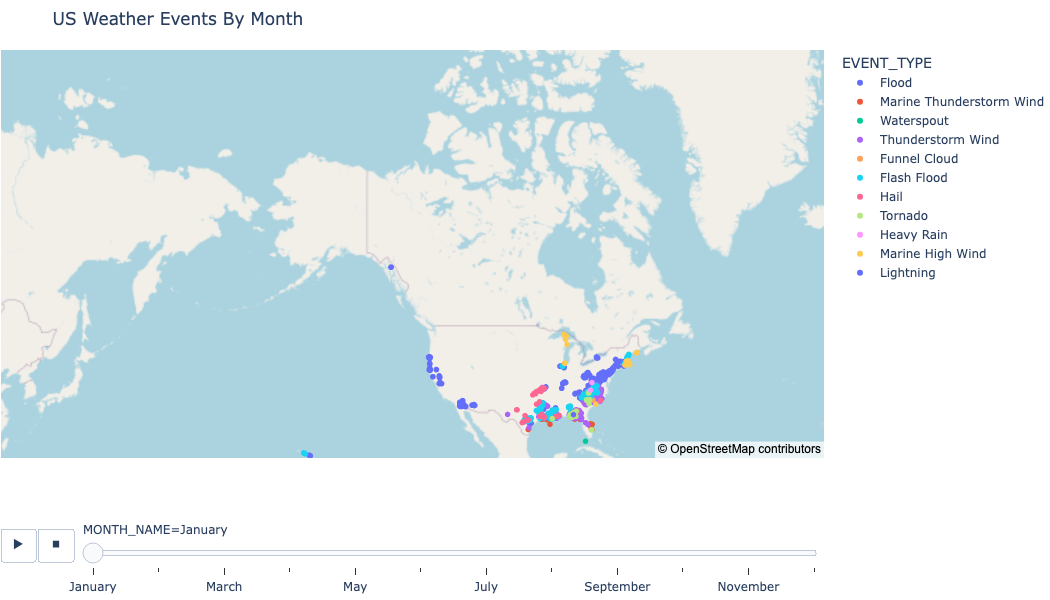

In [31]:
import plotly.express as px
import pandas as pd

fig = px.scatter_mapbox(df, lat='LATITUDE', lon='LONGITUDE',
                          hover_name="LOCATION", zoom=3, animation_frame="MONTH_NAME",
                       hover_data=['EVENT_TYPE'], color='EVENT_TYPE')
fig.update_layout(title='US Weather Events By Month', mapbox_style='open-street-map')
fig.update_layout(autosize=False, width=1000, height=600,margin=dict(l=0, r=0, t=50, b=0))

fig.show()

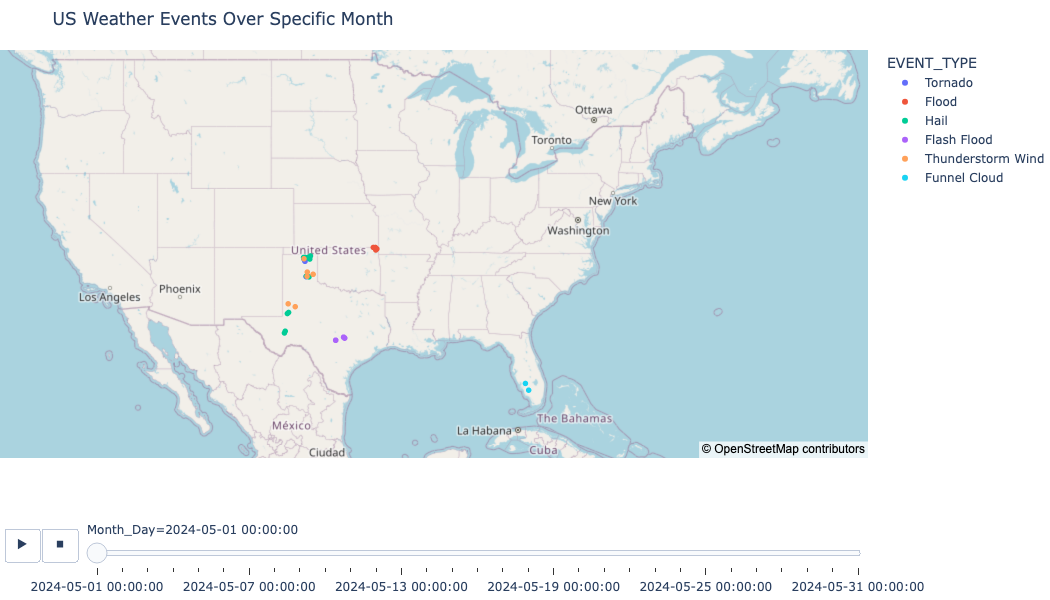

In [32]:
# for one month

df_month = df[df['MONTH_NAME'] == 'May']

fig = px.scatter_mapbox(df_month, lat='LATITUDE', lon='LONGITUDE',
                          hover_name="LOCATION", zoom=3, animation_frame="Month_Day",
                       hover_data=['EVENT_TYPE'], color='EVENT_TYPE')
fig.update_layout(title='US Weather Events Over Specific Month', mapbox_style='open-street-map')
fig.update_layout(autosize=False, width=1000, height=600,margin=dict(l=0, r=0, t=50, b=0))

fig.show()

In [34]:
df.groupby('EVENT_TYPE').size()

EVENT_TYPE
Debris Flow                   409
Dust Devil                     12
Flash Flood                 11593
Flood                        6887
Funnel Cloud                  161
Hail                         4888
Heavy Rain                    534
Lightning                     124
Marine Hail                    22
Marine High Wind               48
Marine Strong Wind              2
Marine Thunderstorm Wind     1594
Thunderstorm Wind           13537
Tornado                      1638
Waterspout                    154
dtype: int64